In [2]:
import os
import sys
from collections import Counter
# Add project path
notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))

# current_file = os.path.abspath(__file__)
# grandparent_dir = os.path.dirname(os.path.dirname(current_file))
# sys.path.insert(0, grandparent_dir)


import numpy as np
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.data import Data
from torch_geometric.typing import Adj
import itertools
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx,
    to_networkx,
    train_test_split_edges,
    to_undirected
)
from torch_geometric.data import Data
from syn_real.custom_wl import (get_graph_orbits,
                                run_wl_test_and_group_nodes)
from syn_real.plotting import plot_graph_with_orbits
from syn_real.measure import (hash_links_by_orbit, 
                              compute_automorphism_metrics,
                              count_automorphic_edges
                            )
from syn_real.auto_operation import (create_disjoint_graph,
                            add_random_edges)
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.data import Data

/home/ka/ka_aifb/ka_cc7738/miniconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=4, node_idx=0, visualize=True):
    """
    Load a dataset and extract a k-hop subgraph around a given node.
    
    Args:
        dataset_name (str): e.g. "Cora", "Citeseer", "PubMed"
        num_hops (int): Number of hops to include in the subgraph
        node_idx (int): Center node to extract from
        visualize (bool): If True, visualize the subgraph

    Returns:
        Data: PyG Data object of the subgraph
    """
    # Load dataset
    dataset = Planetoid(root=f'{dataset_name}', name=dataset_name)
    data = dataset[0]

    # Extract k-hop subgraph
    subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )

    # Create subgraph Data object
    sub_x = data.x[subset]
    sub_y = data.y[subset]
    sub_data = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)

    # Optional visualization
    if visualize:
        G_sub = to_networkx(sub_data, to_undirected=True)
        plt.figure(figsize=(8, 6))
        nx.draw(G_sub, with_labels=True, node_size=300, node_color='skyblue', edge_color='gray')
        plt.title(f"{num_hops}-Hop Subgraph from Node {node_idx} ({dataset_name})")
        plt.axis('off')
        plt.show()

    return sub_data



def plot_orbit_dist(node_groups):
    node_dist = {}
    for node, label in enumerate(node_groups):
        if label not in node_dist:
            node_dist[label] = []
        node_dist[label].append(node)
        
    group_sizes = np.array([len(group) for group in node_dist.values()])
    

    plt.figure(figsize=(6, 4))
    plt.hist(group_sizes, bins=range(min(group_sizes), max(group_sizes) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Size (Dist of Dist)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()



def plot_orbit(orbits):
    plt.figure(figsize=(6, 4))
    plt.hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Orbit Distribution')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()
    


def plot_combined_orbit_graph(G, pos, orbits, edge_class_counts, custom_labels=None, figsize=(18, 6), cmap='tab20b'):
    """
    Combine three plots into one figure with three subplots:
    1. Graph colored by orbit labels
    2. Orbit distribution histogram
    3. Automorphic edge distribution stem plot

    Parameters:
        G (nx.Graph): The graph to plot.
        pos (dict): Node positions.
        orbits (list or array): Orbit label for each node.
        edge_class_counts (dict): Dictionary of edge class counts.
        custom_labels (dict, optional): Dictionary of node labels.
        figsize (tuple): Figure size.
        cmap (str): Matplotlib colormap for nodes.
    """

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # 1. Graph with node colors by orbit labels
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=custom_labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=500,
        font_weight='bold',
        edgecolors='black',
        ax=axs[0]
    )
    axs[0].set_title("Graph Colored by Orbit Labels")

    # 2. Orbit distribution histogram
    axs[1].hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    axs[1].set_xlabel('Orbit Label')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title('Orbit Distribution')
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Automorphic edge distribution stem plot
    unique_orbit_seq = sorted(edge_class_counts.values(), reverse=True)
    axs[2].stem(unique_orbit_seq, markerfmt='bo', basefmt=' ')
    axs[2].set_title('Automorphic Edge Distribution')
    axs[2].set_xlabel("Automorphism Edge Classes")
    axs[2].set_ylabel("Frequency")
    axs[2].grid(True, linestyle='--', alpha=0.7)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()
    plt.savefig('example.pdf')

    
def analyze_automorphisms(data, G):

    _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    orbits, num_orbit = get_graph_orbits(G)
    # print(f"Number of orbits: {num_orbit}")

    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    count_automorphic_edges(G, orbits)
    
    # metrics, num_nodes, group_sizes = compute_automorphism_metrics(orbits, G.number_of_nodes())
    
    # plot_orbit_dist(orbits)
    # plot_graph_with_orbits(G, 
    #                        None, 
    #                        orbits, 
    #                        custom_labels=custom_labels, 
    #                        figsize=(8, 6), cmap='tab20b')
    # plot_orbit(orbits)
    edge_class_counts, _ = hash_links_by_orbit(G, orbits)
    from syn_real.plotting import plot_unique_edge_class
    # plot_unique_edge_class(edge_class_counts)

    plot_combined_orbit_graph(G, None, orbits, edge_class_counts, custom_labels=custom_labels)
    return orbits

In [4]:

def add_isolated_node_for_node(data, node_idx, copy_feature=True):
    """
    Add one isolated node to the graph, associated with a given node (no edges).
    
    Args:
        data (Data): Original PyG data object.
        node_idx (int): Index of the node to associate the new isolated node with.
        copy_feature (bool): If True, copy the feature of the given node; else zero vector.
    
    Returns:
        Data: New PyG data object with an isolated node added.
    """
    assert node_idx < data.num_nodes, "node_idx out of range"

    # 1. Add new node feature
    F = data.x.size(1)
    if copy_feature:
        new_feat = data.x[node_idx].unsqueeze(0)  # shape: [1, F]
    else:
        new_feat = torch.zeros((1, F))

    new_x = torch.cat([data.x, new_feat], dim=0)

    # 2. Add dummy label for new node if labels exist
    if data.y is not None:
        new_y = torch.cat([data.y, torch.tensor([-1], dtype=data.y.dtype)])
    else:
        new_y = None

    # 3. edge_index stays unchanged (new node is isolated)
    new_data = Data(x=new_x, edge_index=data.edge_index, y=new_y)

    # 4. Track association to original node
    new_data.original_node_ids = torch.cat([
        getattr(data, 'original_node_ids', torch.arange(data.num_nodes)),
        torch.tensor([node_idx])
    ])

    return new_data

In [5]:
import torch
from torch_geometric.data import Data

def add_node_connected_to_node(data, node_idx, copy_feature=True, undirected=True):
    """
    Add one new node to the graph and connect it with an edge to the given node.
    
    Args:
        data (Data): Original PyG data object.
        node_idx (int): Index of the node to connect the new node to.
        copy_feature (bool): If True, copy the feature of the given node; else zero vector.
        undirected (bool): If True, add bidirectional edge.
    
    Returns:
        Data: New PyG data object with a connected node added.
    """
    assert node_idx < data.num_nodes, "node_idx out of range"

    F = data.x.size(1)
    if copy_feature:
        new_feat = data.x[node_idx].unsqueeze(0)  
    else:
        new_feat = torch.zeros((1, F))
    
    new_x = torch.cat([data.x, new_feat], dim=0)
    if data.y is not None:
        new_y = torch.cat([data.y, torch.tensor([-1], dtype=data.y.dtype)])
    else:
        new_y = None

    new_node_id = data.num_nodes
    edges = [[new_node_id, node_idx]]
    if undirected:
        edges.append([node_idx, new_node_id])

    edge_add = torch.tensor(edges, dtype=torch.long).t()  
    new_edge_index = torch.cat([data.edge_index, edge_add], dim=1)

    new_data = Data(x=new_x, edge_index=new_edge_index, y=new_y)
    return new_data

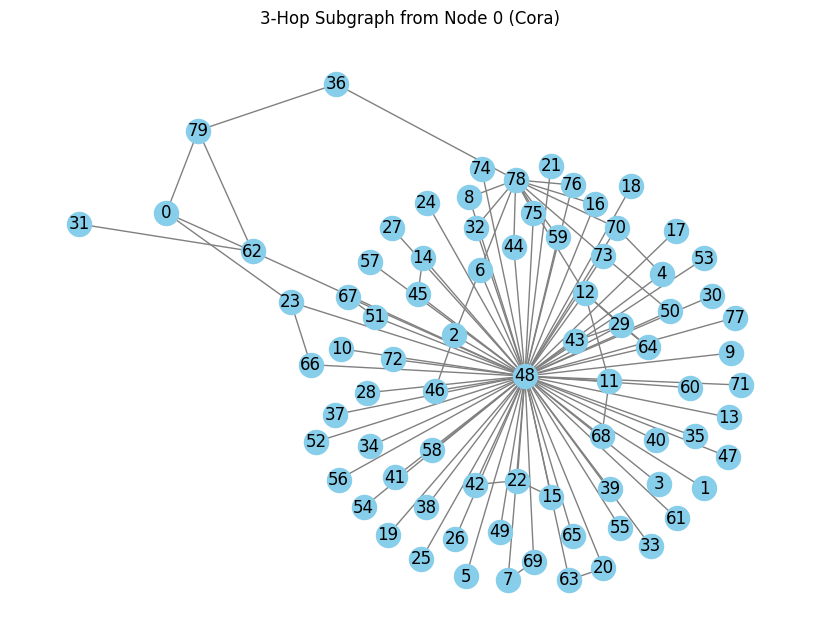

Before:
Num nodes: 80
Num edges: 218
Intra-orbit edges: 1725, Inter-orbit edges: 4314
Non-distinguishable edges: 6039


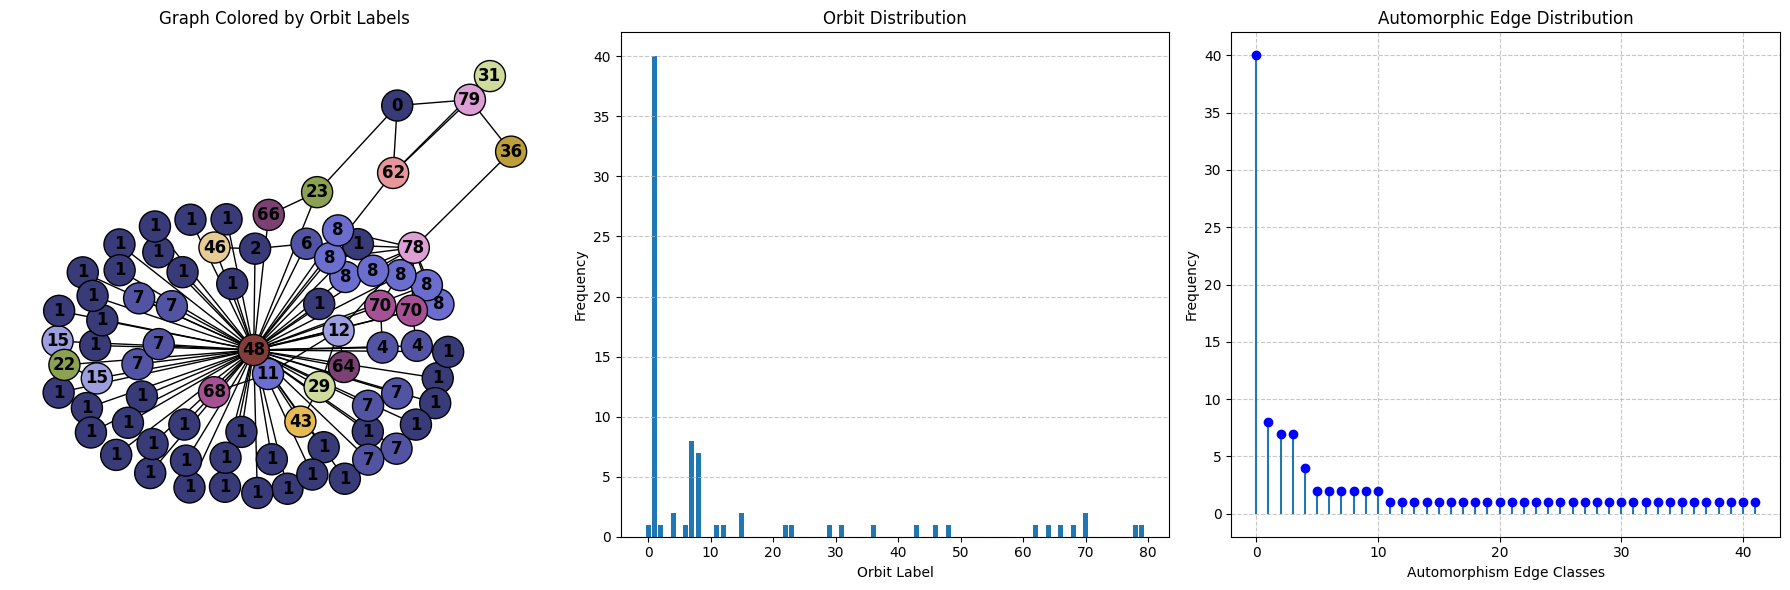

New nodes: 81
New edges: 220
Number of nodes in the graph: 81
Intra-orbit edges: 1806, Inter-orbit edges: 4394
Non-distinguishable edges: 6200


<Figure size 640x480 with 0 Axes>

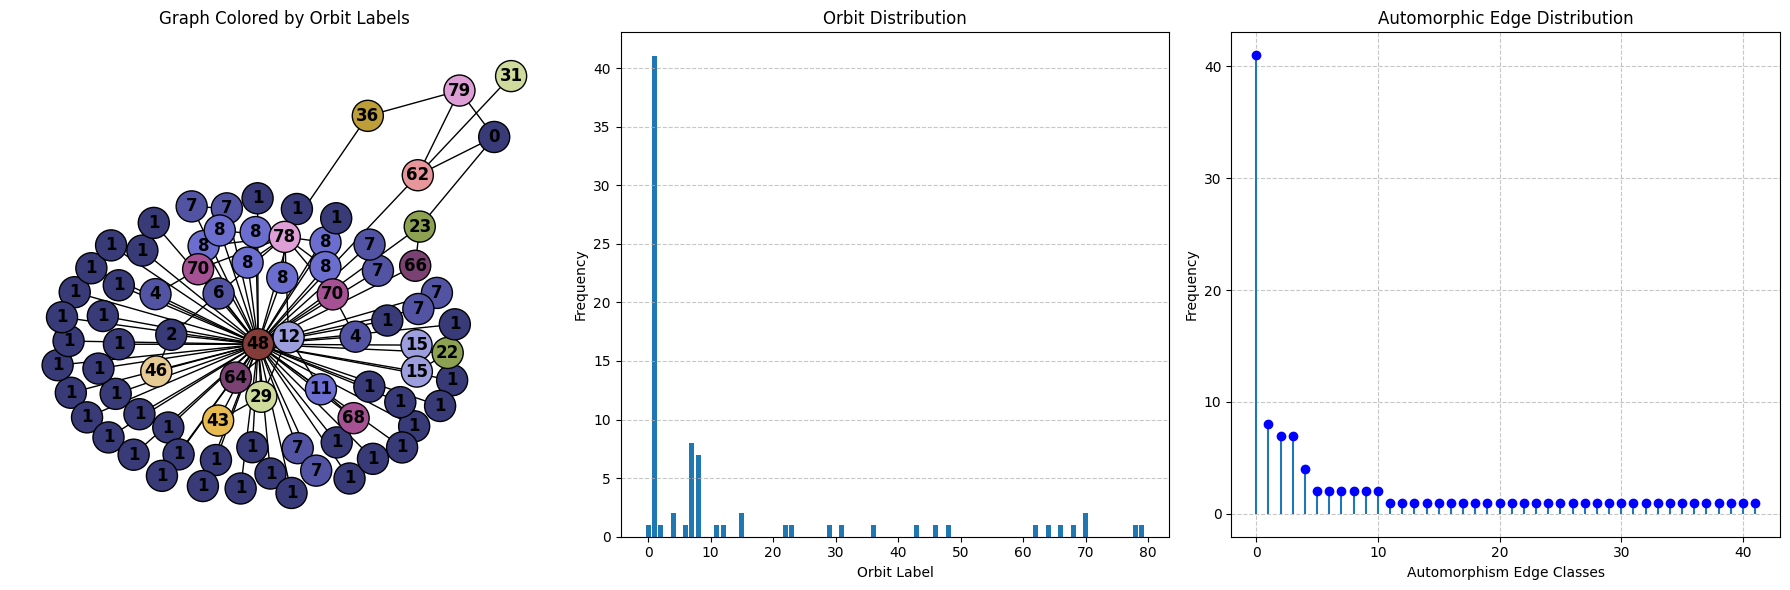

New nodes: 82
New edges: 222
Number of nodes in the graph: 82
Intra-orbit edges: 1889, Inter-orbit edges: 4474
Non-distinguishable edges: 6363


<Figure size 640x480 with 0 Axes>

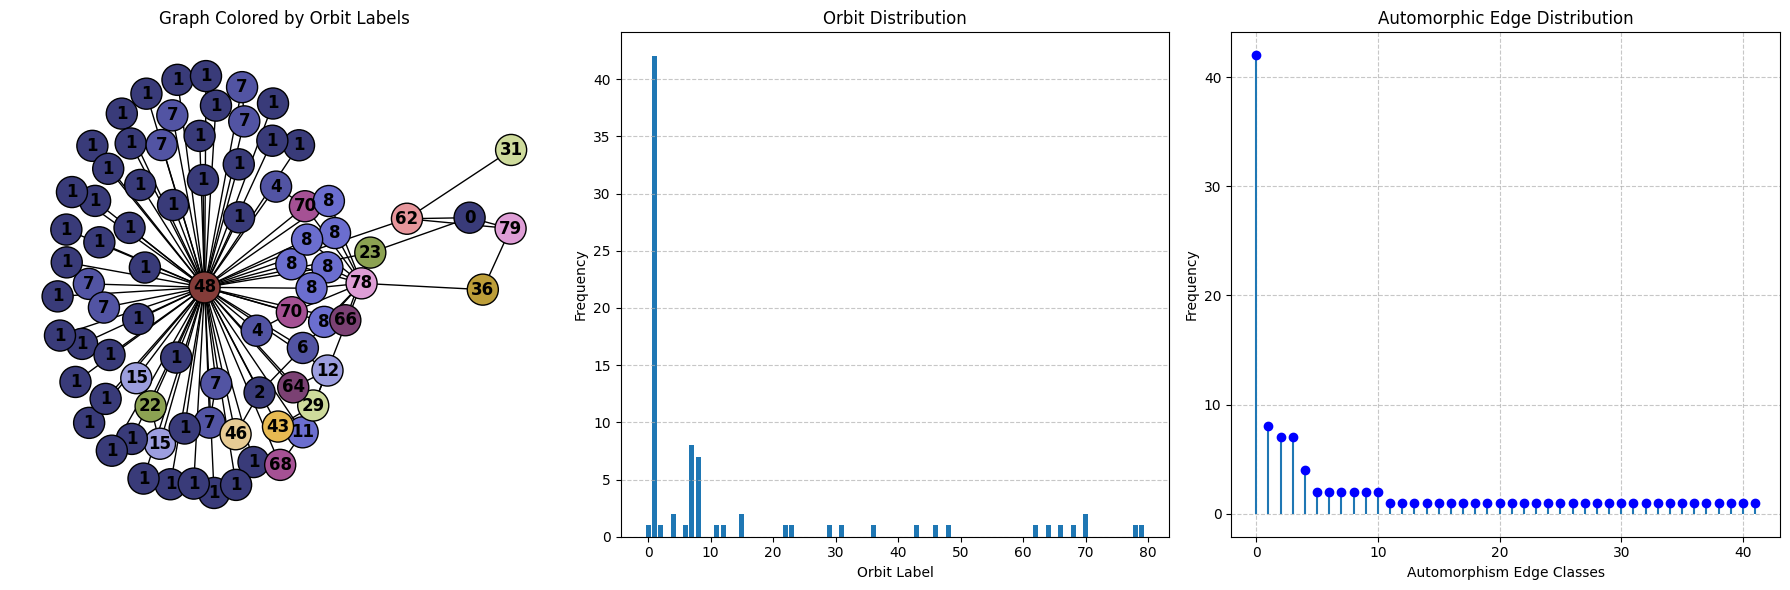

New nodes: 83
New edges: 224
Number of nodes in the graph: 83
Intra-orbit edges: 1974, Inter-orbit edges: 4554
Non-distinguishable edges: 6528


<Figure size 640x480 with 0 Axes>

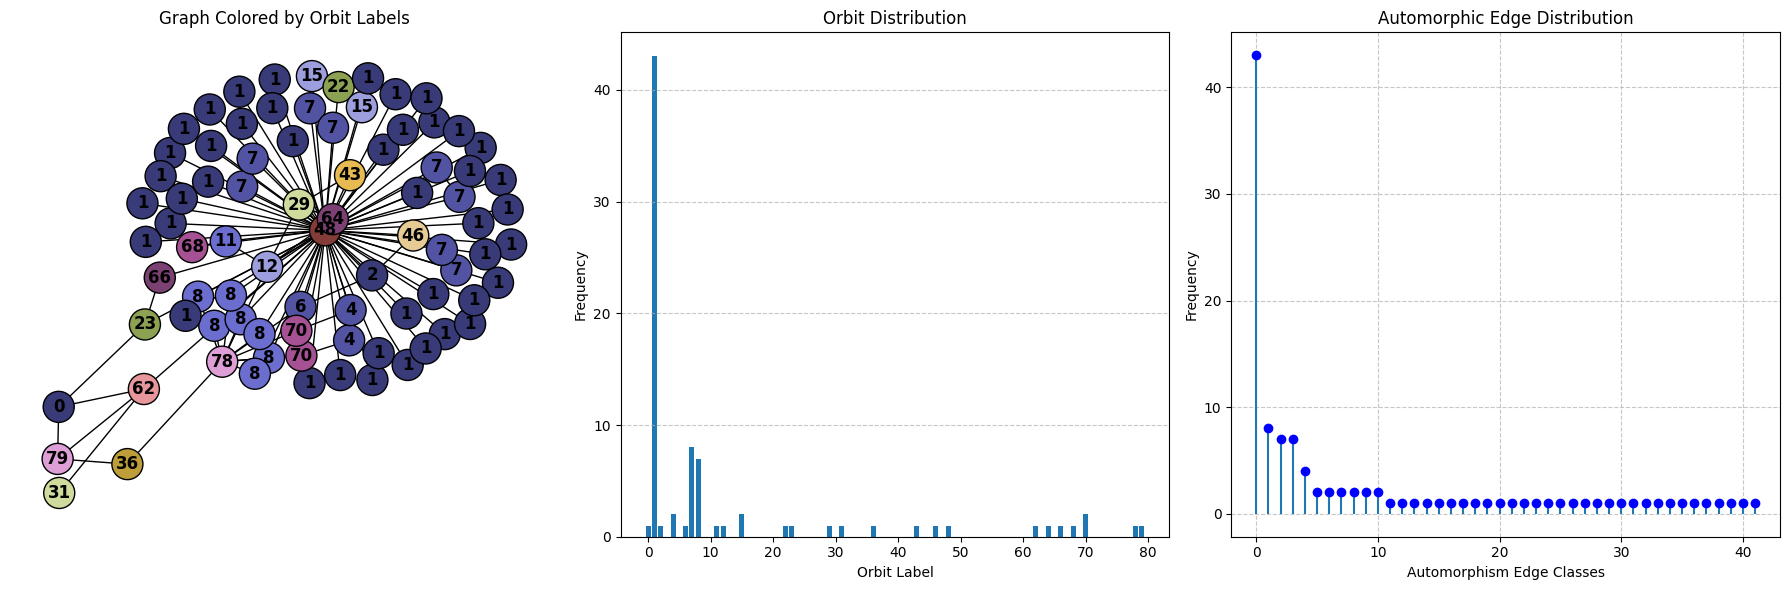

New nodes: 84
New edges: 226
Number of nodes in the graph: 84
Intra-orbit edges: 2061, Inter-orbit edges: 4634
Non-distinguishable edges: 6695


<Figure size 640x480 with 0 Axes>

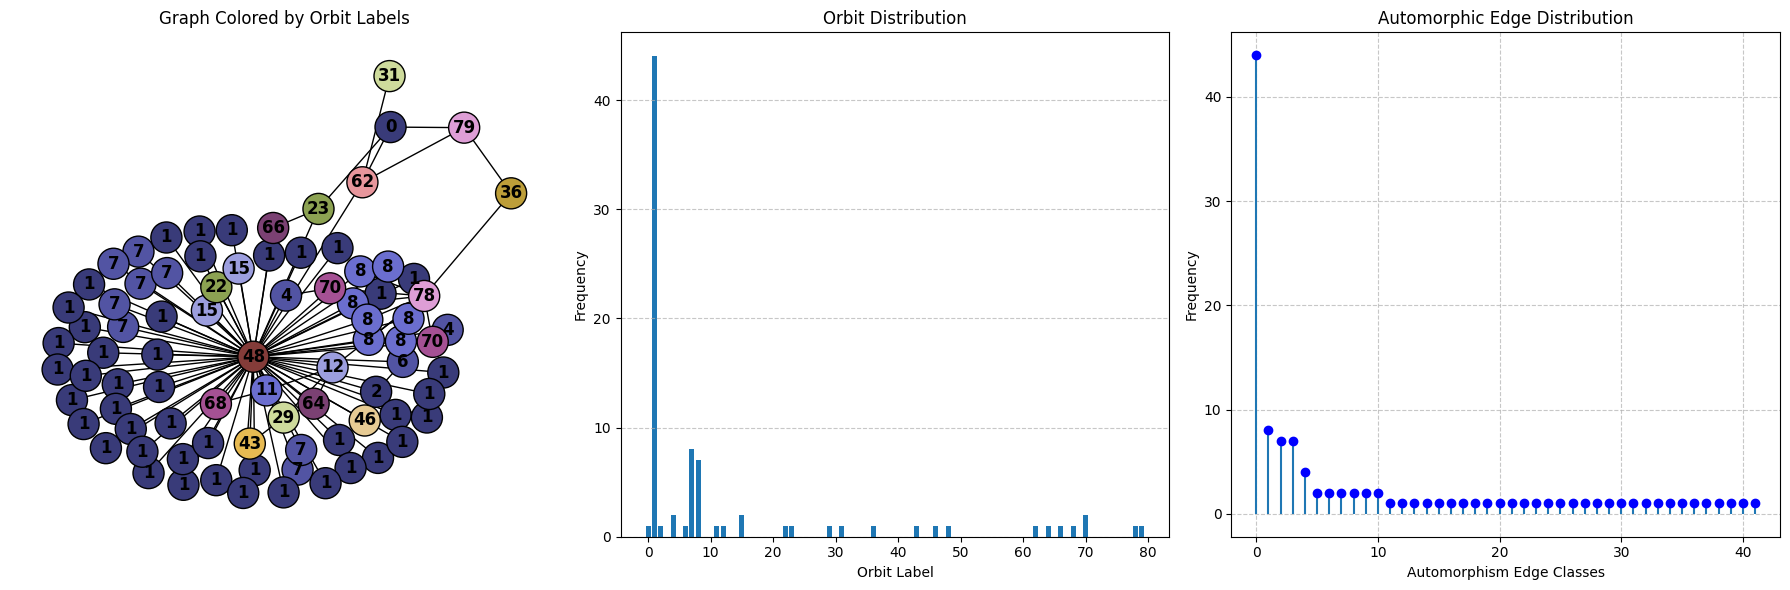

New nodes: 85
New edges: 228
Number of nodes in the graph: 85
Intra-orbit edges: 2150, Inter-orbit edges: 4714
Non-distinguishable edges: 6864


<Figure size 640x480 with 0 Axes>

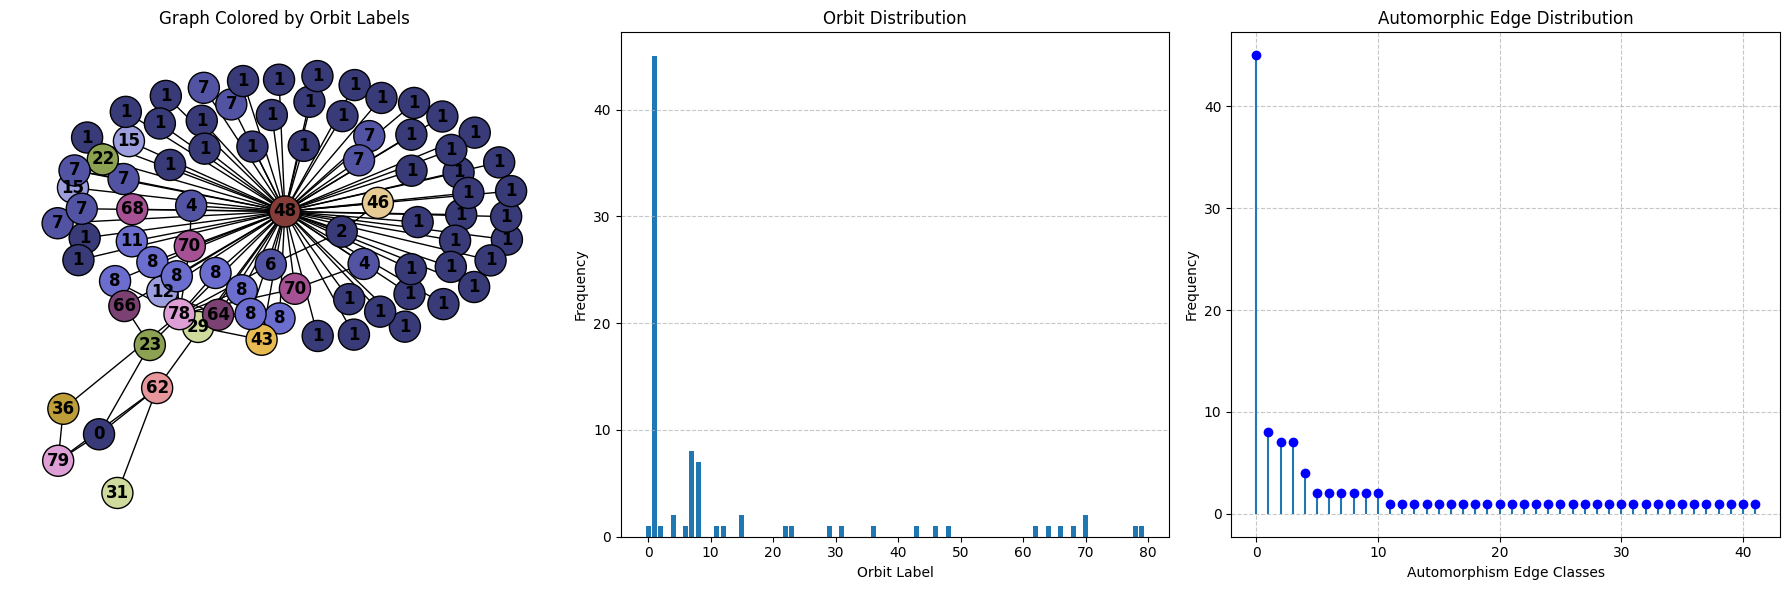

New nodes: 86
New edges: 230
Number of nodes in the graph: 86
Intra-orbit edges: 2241, Inter-orbit edges: 4794
Non-distinguishable edges: 7035


<Figure size 640x480 with 0 Axes>

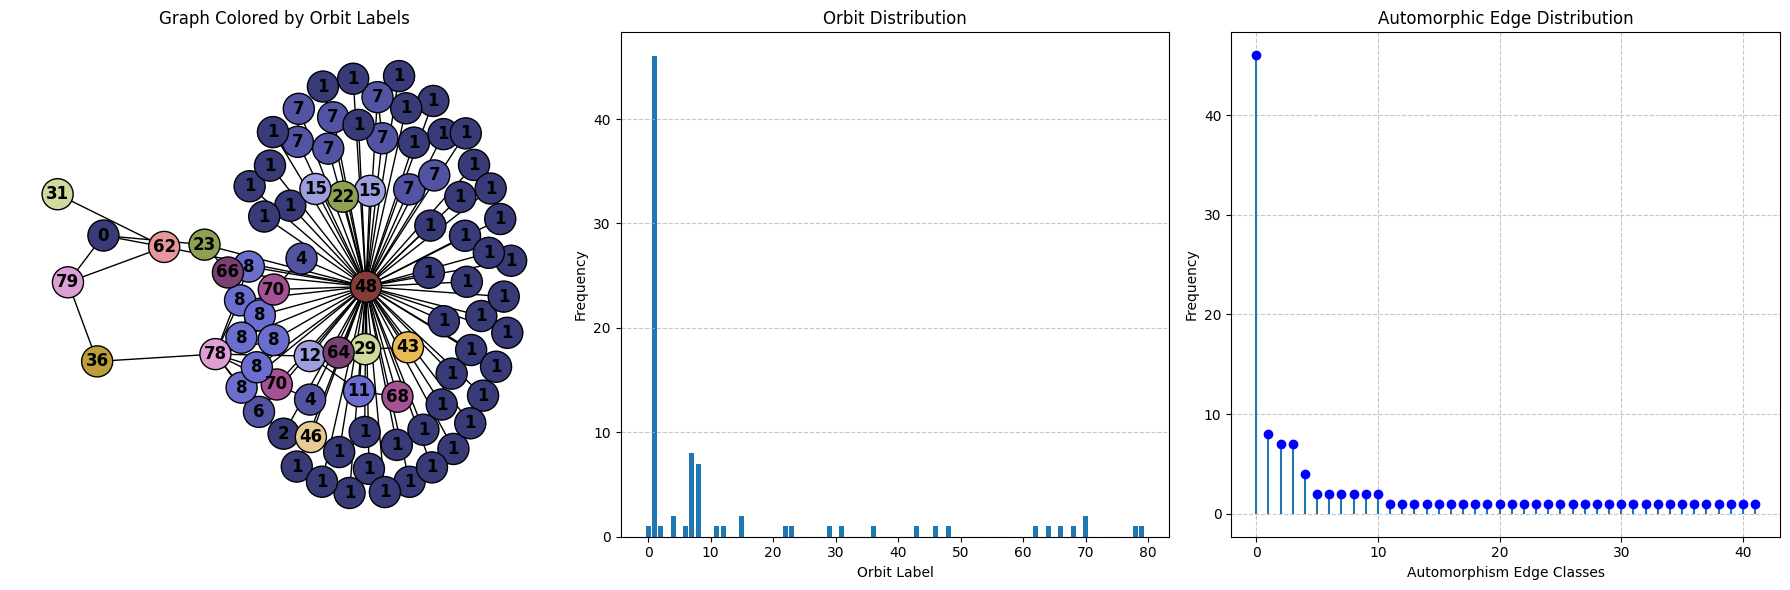

New nodes: 87
New edges: 232
Number of nodes in the graph: 87
Intra-orbit edges: 2334, Inter-orbit edges: 4874
Non-distinguishable edges: 7208


<Figure size 640x480 with 0 Axes>

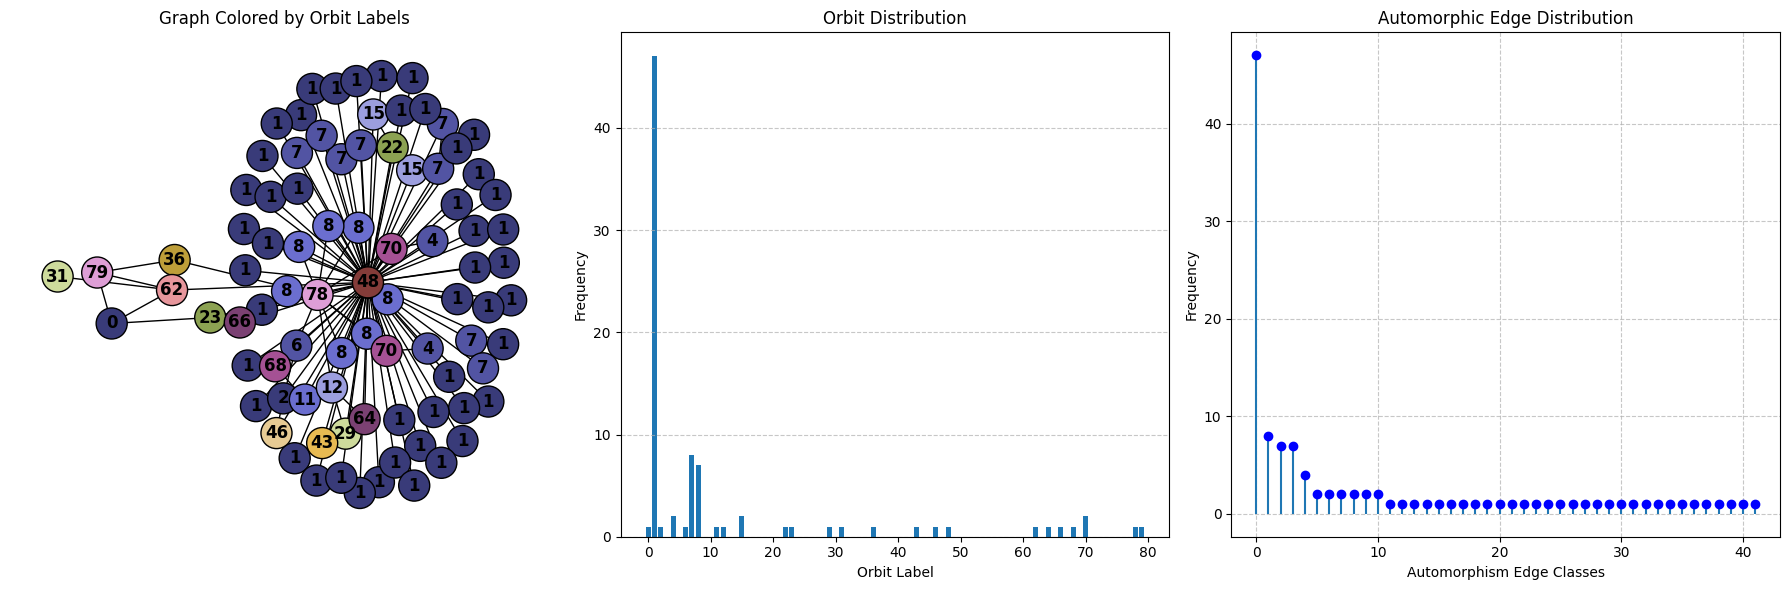

New nodes: 88
New edges: 234
Number of nodes in the graph: 88
Intra-orbit edges: 2429, Inter-orbit edges: 4954
Non-distinguishable edges: 7383


<Figure size 640x480 with 0 Axes>

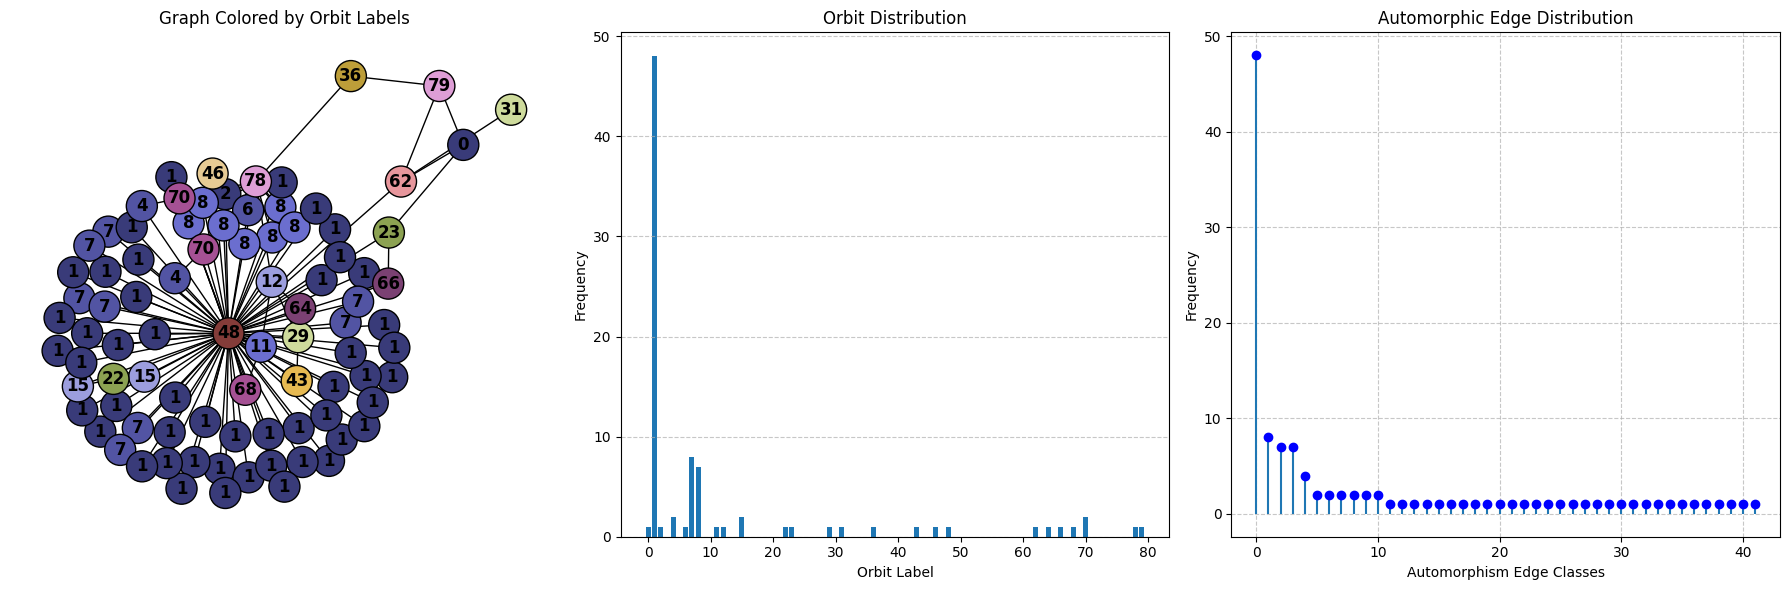

New nodes: 89
New edges: 236
Number of nodes in the graph: 89
Intra-orbit edges: 2526, Inter-orbit edges: 5034
Non-distinguishable edges: 7560


<Figure size 640x480 with 0 Axes>

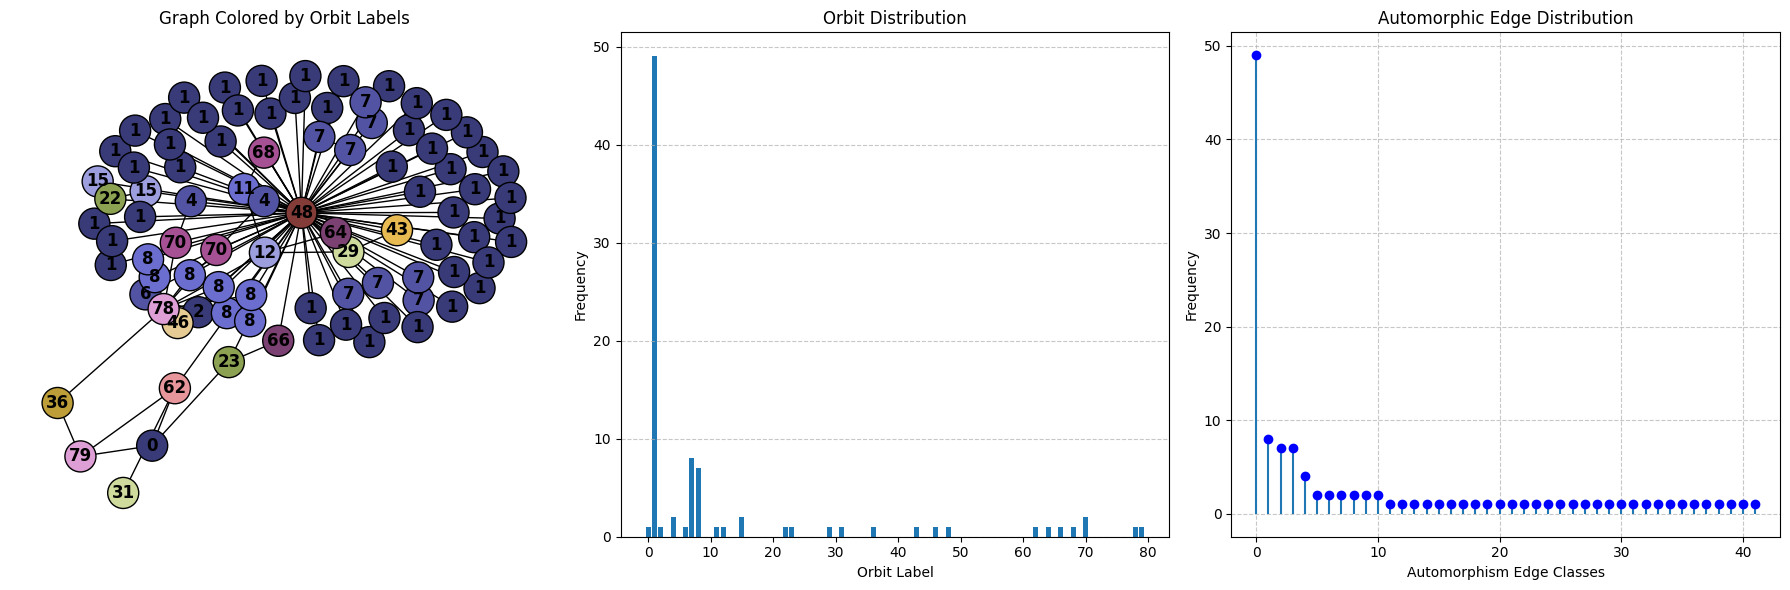

New nodes: 90
New edges: 238
Number of nodes in the graph: 90
Intra-orbit edges: 2625, Inter-orbit edges: 5114
Non-distinguishable edges: 7739


<Figure size 640x480 with 0 Axes>

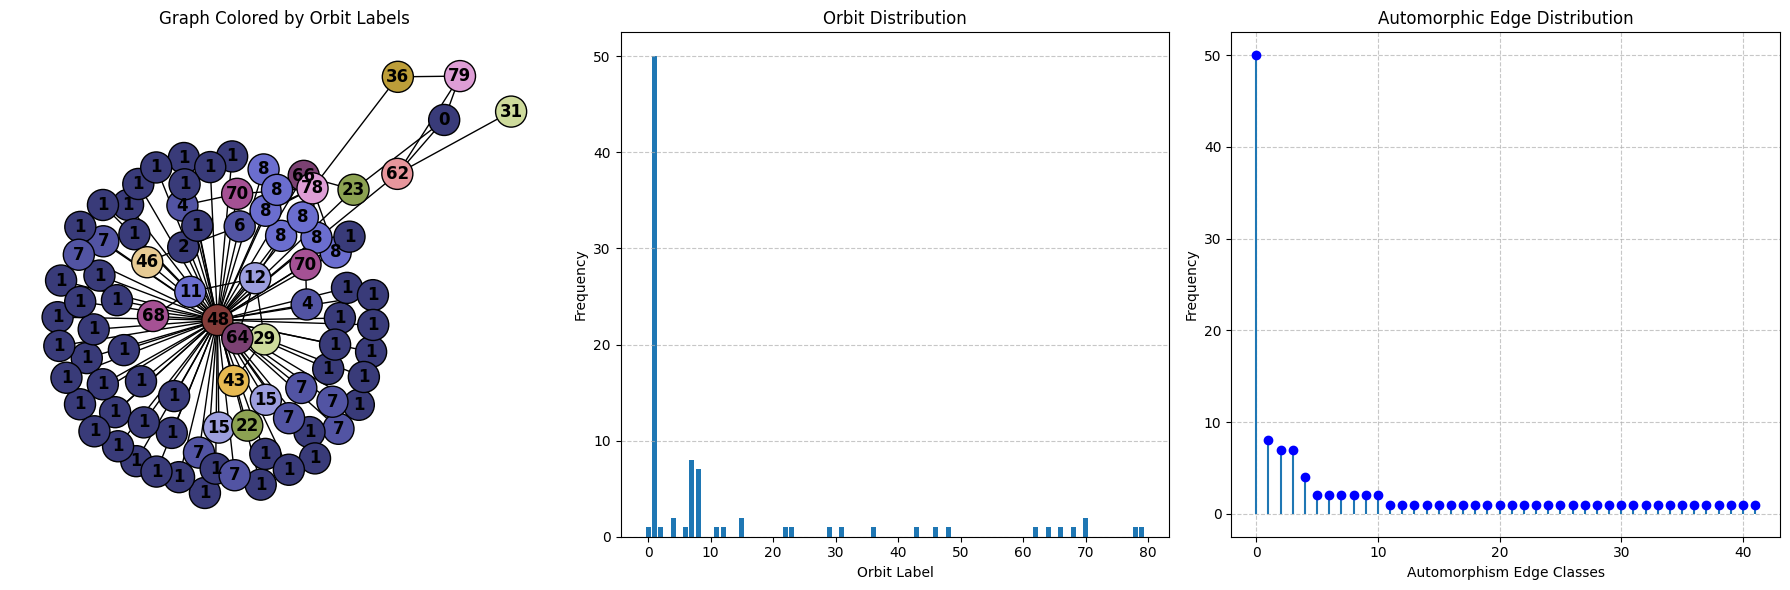

<Figure size 640x480 with 0 Axes>

In [7]:
data = get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=3, node_idx=0, visualize=True)
print("Before:")
print("Num nodes:", data.num_nodes)
print("Num edges:", data.edge_index.size(1))

G = to_networkx(data, to_undirected=True)
analyze_automorphisms(data, G)
aug_data = data
for i in range(10):
    
	aug_data = add_node_connected_to_node(aug_data, node_idx=48, copy_feature=True)


	print("New nodes:", aug_data.num_nodes)
	print("New edges:", aug_data.edge_index.size(1))

	aug_G = to_networkx(aug_data, to_undirected=True)

	print(f"Number of nodes in the graph: {aug_data.num_nodes}")
	analyze_automorphisms(aug_data, aug_G)

Original nodes: 80
New nodes: 91
Intra-orbit edges: 2621, Inter-orbit edges: 5176
Non-distinguishable edges: 7797


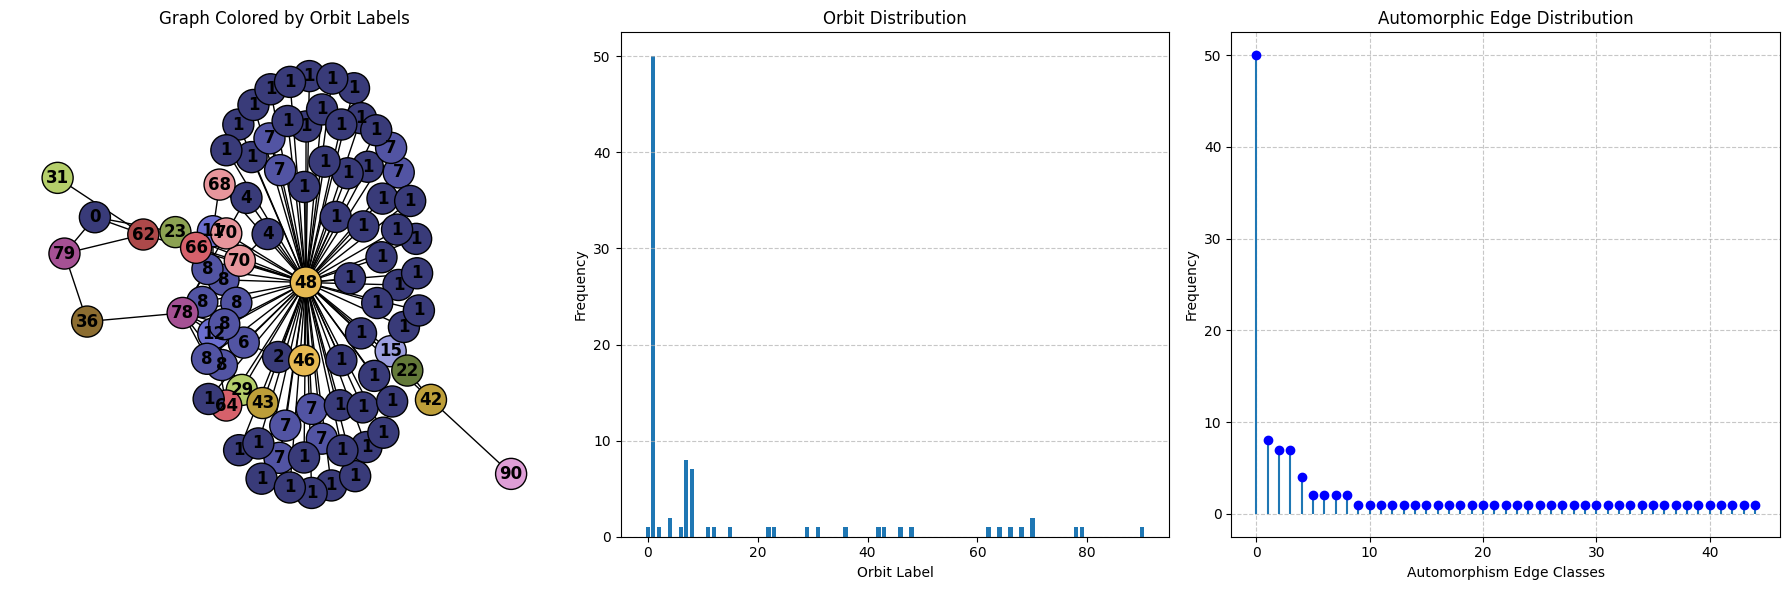

[0,
 1,
 2,
 1,
 4,
 1,
 6,
 7,
 8,
 1,
 1,
 11,
 12,
 1,
 7,
 15,
 8,
 1,
 1,
 1,
 7,
 1,
 22,
 23,
 1,
 1,
 1,
 1,
 1,
 29,
 1,
 31,
 8,
 1,
 1,
 1,
 36,
 1,
 1,
 1,
 1,
 1,
 42,
 43,
 8,
 7,
 46,
 1,
 48,
 1,
 4,
 7,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 8,
 1,
 1,
 62,
 7,
 64,
 1,
 66,
 7,
 68,
 7,
 70,
 1,
 1,
 70,
 1,
 8,
 8,
 1,
 78,
 79,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 90]

<Figure size 640x480 with 0 Axes>

In [8]:
# Add one node connected to node 42
aug_data = add_node_connected_to_node(aug_data, node_idx=42, copy_feature=True)

print("Original nodes:", data.num_nodes)
print("New nodes:", aug_data.num_nodes)

aug_G = to_networkx(aug_data, to_undirected=True)
analyze_automorphisms(aug_data, aug_G)

In [ ]:
# inter_ratio = 1
# intra_ratio = 1
# total_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# interval = 1
# for edges in total_edges:
#     if inter_ratio != 0 and intra_ratio != 0 and total_edges != 0:
#         updated_graph_data = add_random_edges(data, inter_ratio=inter_ratio, total_edges=edges*interval*10)
#         # rewired_data = rewire_edges_regularly(data, keep_prob=0.6)
#     else:
#         updated_graph_data = data
    
#     G = to_networkx(updated_graph_data, to_undirected=True)
#     analyze_automorphisms(updated_graph_data, G)